In [2]:
import pandas as pd

df = pd.read_excel("../data/Coffee Shop Sales.xlsx")

df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [3]:
df.shape

(149116, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[us]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  str           
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  str           
 9   product_type      149116 non-null  str           
 10  product_detail    149116 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(4), object(1), str(4)
memory usage: 12.5+ MB


In [5]:
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [6]:
df["revenue"] = df["transaction_qty"] * df["unit_price"]

In [7]:
df["revenue"].sum()

np.float64(698812.3300000001)

In [8]:
round(df["revenue"].sum(), 2)

np.float64(698812.33)

In [9]:
# daily revenue trend and store comparison.
daily_revenue = (df.groupby("transaction_date")["revenue"].sum().reset_index())

daily_revenue.head()

,transaction_date,revenue
0,2023-01-01,2508.20
1,2023-01-02,2403.35
2,2023-01-03,2565.00
3,2023-01-04,2220.10
4,2023-01-05,2418.85


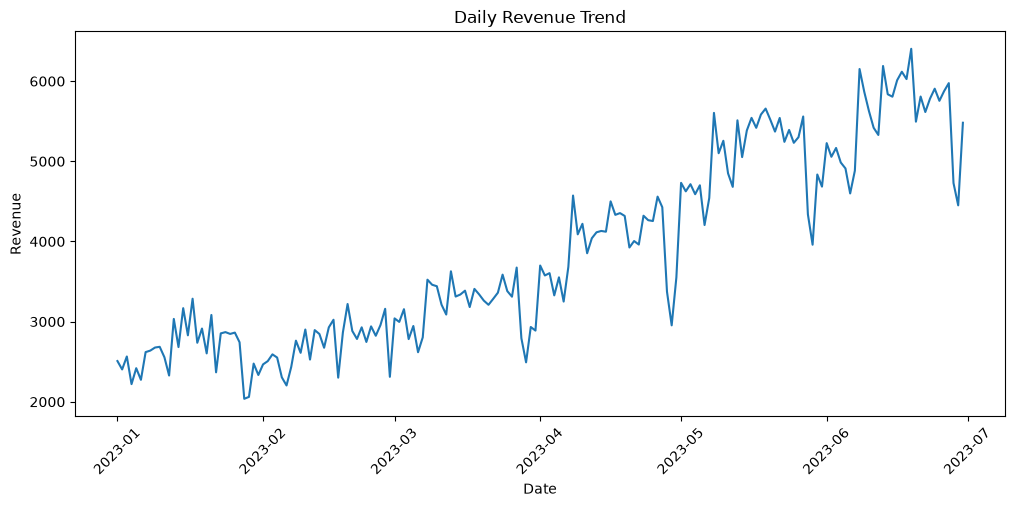

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(daily_revenue["transaction_date"], daily_revenue["revenue"])

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [11]:
store_summary = (
    df.groupby("store_location")
      .agg(
          total_revenue=("revenue", "sum"),
          total_transactions=("transaction_id", "nunique"),
          total_units_sold=("transaction_qty", "sum")
      )
      .reset_index()
)

store_summary["avg_order_value"] = (
    store_summary["total_revenue"]
    / store_summary["total_transactions"]
)

store_summary

,store_location,total_revenue,total_transactions,total_units_sold,avg_order_value
0,Astoria,232243.91,50599,70991,4.589891
1,Hell's Kitchen,236511.17,50735,71737,4.661696
2,Lower Manhattan,230057.25,47782,71742,4.814726


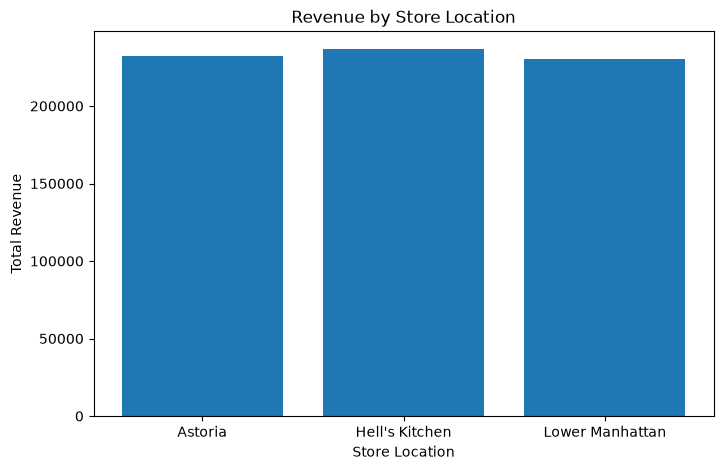

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    store_summary["store_location"],
    store_summary["total_revenue"]
)

plt.title("Revenue by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Total Revenue")

plt.show()

In [13]:
# daily revenue distribution and unusual sales days
daily_revenue.head()

,transaction_date,revenue
0,2023-01-01,2508.20
1,2023-01-02,2403.35
2,2023-01-03,2565.00
3,2023-01-04,2220.10
4,2023-01-05,2418.85


In [14]:
daily_revenue["revenue"].describe()


count     181.000000
mean     3860.841602
std      1187.822030
min      2037.100000
25%      2853.150000
50%      3523.260000
75%      4850.060000
max      6403.910000
Name: revenue, dtype: float64

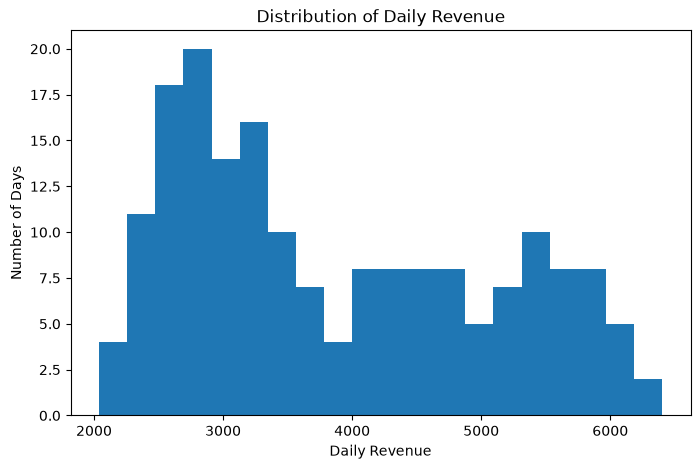

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(daily_revenue["revenue"], bins=20)

plt.title("Distribution of Daily Revenue")
plt.xlabel("Daily Revenue")
plt.ylabel("Number of Days")

plt.show()

In [16]:
daily_revenue.nlargest(5, "revenue")

,transaction_date,revenue
169,2023-06-19,6403.91
163,2023-06-13,6189.36
158,2023-06-08,6151.59
167,2023-06-17,6117.60
168,2023-06-18,6026.09


In [17]:
daily_revenue.nsmallest(5, "revenue")

,transaction_date,revenue
27,2023-01-28,2037.10
28,2023-01-29,2060.75
36,2023-02-06,2203.40
3,2023-01-04,2220.10
5,2023-01-06,2273.85


In [18]:
# Do a small number of products generate most of the revenue?
product_revenue = (
    df.groupby("product_type")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

product_revenue["revenue_pct"] = (
    product_revenue["revenue"]
    / product_revenue["revenue"].sum()
    * 100
)

product_revenue["cumulative_pct"] = (
    product_revenue["revenue_pct"].cumsum()
)

product_revenue.head(10)

,product_type,revenue,revenue_pct,cumulative_pct
0,Barista Espresso,91406.20,13.080221,13.080221
1,Brewed Chai tea,77081.95,11.030422,24.110644
2,Hot chocolate,72416.00,10.362725,34.473369
3,Gourmet brewed coffee,70034.60,10.021947,44.495315
4,Brewed Black tea,47932.00,6.859066,51.354382
5,Brewed herbal tea,47539.50,6.802899,58.157281
6,Premium brewed coffee,38781.15,5.549580,63.706861
7,Organic brewed coffee,37746.50,5.401522,69.108383
8,Scone,36866.12,5.275539,74.383922
9,Drip coffee,31984.00,4.576908,78.960831


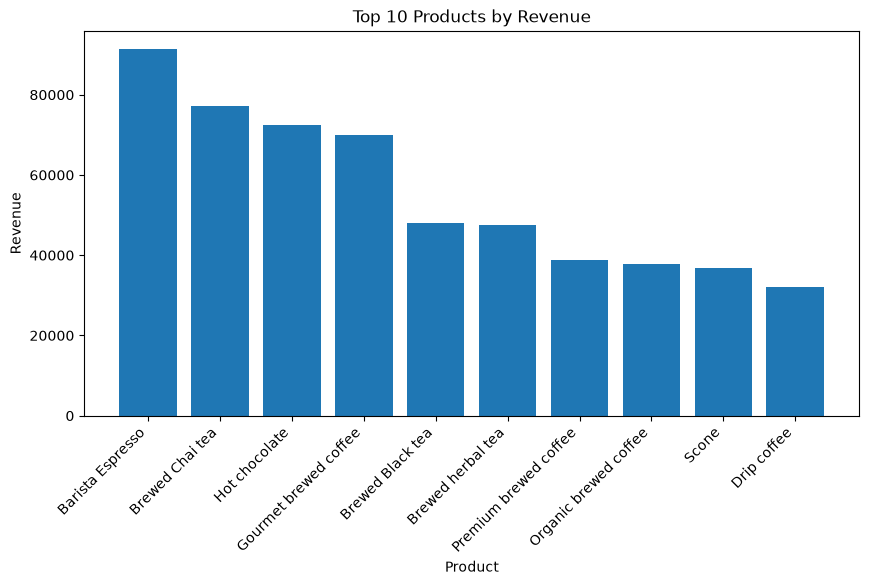

In [19]:
top10 = product_revenue.head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top10["product_type"],
    top10["revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")

plt.show()

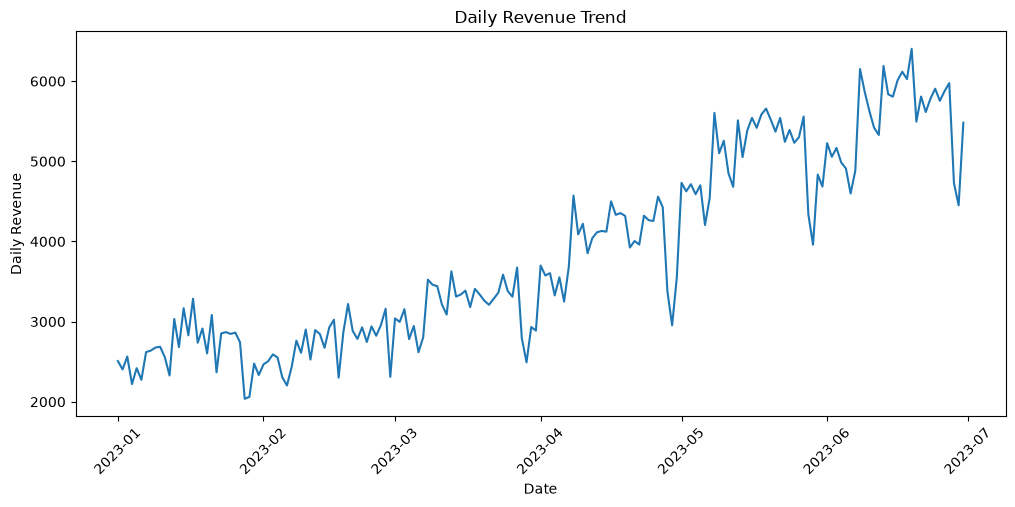

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_revenue["transaction_date"],
    daily_revenue["revenue"]
)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Daily Revenue")
plt.xticks(rotation=45)

plt.show()